## Shor's Algorithm: Factoring N = 15 in Qiskit

**4i Labs Quantum Computing Domain · IIT Guwahati · Tenure 2026–27**

---

### Overview

In this project you will implement **Shor's Algorithm** in Qiskit to factor $N = 15$.

Shor's algorithm is one of the most celebrated quantum algorithms. It demonstrates an **exponential speedup** over the best known classical factoring algorithms and directly threatens RSA encryption — making it one of the most practically significant results in quantum computing.

The algorithm has two parts:
1. **Quantum part** — Use quantum phase estimation (built around the QFT) to find the *period* $r$ of the function $f(x) = a^x \bmod N$
2. **Classical part** — Use Euler's theorem to extract factors of $N$ from $r$

### What is pre-written for you
The **modular exponentiation oracle** (the $U_f$ circuit that computes $a^x \bmod 15$) has been implemented for you. This is the hardest part of the circuit to construct from scratch.

### What you need to complete
- ✅ **Step 2** — Build the inverse QFT circuit
- ✅ **Step 3** — Assemble the full Shor's circuit
- ✅ **Step 4** — Run on the Aer simulator and extract the period
- ✅ **Step 5** — Classical post-processing to find the factors
- ✅ **Step 6** — Run on real IBM Quantum hardware and compare results

### Submission
Submit your completed `.ipynb` notebook file via the course portal.

---
> **Note:** Work through each cell in order. Cells marked `# YOUR CODE HERE` require your implementation. Read all markdown explanations carefully before coding.


## Step 0 — Setup and Imports

Run the cell below to install and import all required libraries.

In [1]:
# Install Qiskit if not already installed
# !pip install qiskit qiskit-aer qiskit-ibm-runtime

import numpy as np
import matplotlib.pyplot as plt
from math import gcd, pi

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_histogram, circuit_drawer
from qiskit_aer import AerSimulator
from fractions import Fraction

print("✅ All imports successful")


✅ All imports successful


---
## Background: How Shor's Algorithm Works

Shor's algorithm factors $N$ by reducing the problem to **period finding**:

1. Pick a random integer $a$ where $1 < a < N$ and $\gcd(a, N) = 1$
2. Define $f(x) = a^x \bmod N$ — this function is **periodic** with some period $r$
3. Use the quantum circuit to find $r$
4. Use $r$ to compute $\gcd(a^{r/2} \pm 1, N)$ — these are the factors of $N$

For $N = 15$, we will use $a = 7$.

**Why $a = 7$?**
- $\gcd(7, 15) = 1$ ✓ (so they share no common factors)
- The period of $f(x) = 7^x \bmod 15$ is $r = 4$ (you will verify this!)

Let's first verify this classically:


In [2]:
# Verify the period of f(x) = 7^x mod 15 classically
a = 7
N = 15

print(f"Computing f(x) = {a}^x mod {N}:")
print("-" * 30)
for x in range(9):
    fx = pow(a, x, N)
    print(f"  f({x}) = {a}^{x} mod {N} = {fx}")

print()
print("What period do you observe? Note it down — you will verify it from")
print("the quantum circuit output in Step 4.")


Computing f(x) = 7^x mod 15:
------------------------------
  f(0) = 7^0 mod 15 = 1
  f(1) = 7^1 mod 15 = 7
  f(2) = 7^2 mod 15 = 4
  f(3) = 7^3 mod 15 = 13
  f(4) = 7^4 mod 15 = 1
  f(5) = 7^5 mod 15 = 7
  f(6) = 7^6 mod 15 = 4
  f(7) = 7^7 mod 15 = 13
  f(8) = 7^8 mod 15 = 1

What period do you observe? Note it down — you will verify it from
the quantum circuit output in Step 4.


## we found Period = 4, from observation

---
## Step 1 — Modular Exponentiation Oracle (Pre-Written)

The circuit below implements the **controlled-$U^{2^j}$** operation where $U|y\rangle = |ay \bmod N\rangle$.

For $a = 7$, $N = 15$, the oracle is a 4-qubit circuit acting on the *target register*.
This is the hardest part of Shor's circuit and has been implemented for you.

> **Read through this cell carefully** — understanding what the oracle does is important for assembling the full circuit in Step 3.


In [3]:
def c_amod15(a, power):
    """
    Controlled-U gate where U|y> = |a*y mod 15>.
    Pre-written oracle for a in {2, 4, 7, 8, 11, 13} and N = 15.

    Parameters:
        a (int)     : base for modular exponentiation (use a=7)
        power (int) : the power to raise a to (2^j in the QPE circuit)

    Returns:
        gate : a controlled quantum gate
    """
    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError("'a' must be coprime to 15 and in {2,4,7,8,11,13}")

    U = QuantumCircuit(4)
    for _iteration in range(power):
        if a in [2, 13]:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
        if a in [7, 8]:
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
        if a in [4, 11]:
            U.swap(1, 3)
            U.swap(0, 2)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)

    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control()
    return c_U

# Test: build one instance to confirm it works
test_gate = c_amod15(7, 1)
print(f"✅ Oracle created: {test_gate.name}")
print(f"   Number of qubits (including control): {test_gate.num_qubits}")


✅ Oracle created: c7^1 mod 15
   Number of qubits (including control): 5


---
## Step 2 — Build the Inverse QFT (Your Task)

The **Quantum Fourier Transform (QFT)** is the quantum analogue of the FFT.
In Shor's algorithm, we apply the **inverse QFT** to the counting register
at the end of the circuit to convert phase information into a measurable
frequency — from which we extract the period $r$.

### The QFT circuit structure
For $n$ qubits, the QFT consists of:
1. A **Hadamard gate** on each qubit
2. **Controlled phase rotation gates** $R_k = \begin{pmatrix} 1 & 0 \\ 0 & e^{2\pi i / 2^k} \end{pmatrix}$ applied between qubits
3. **SWAP gates** at the end to reverse qubit ordering

The **inverse QFT** is simply the QFT circuit run in reverse (conjugate transpose).

### Your task
Complete the `qft_dagger` function below which builds the **inverse QFT** on `n` qubits.


In [6]:
def qft_dagger(n):
    """
    Build the inverse Quantum Fourier Transform circuit on n qubits.

    Parameters:
        n (int) : number of qubits

    Returns:
        qc (QuantumCircuit) : the inverse QFT circuit
    """
    qc = QuantumCircuit(n)

    #Step 1: Swap qubits to reverse ordering
    for qubit in range(n // 2):
        qc.swap(qubit, n - qubit - 1)


    # Step 2: Apply inverse QFT rotations
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi / float(2 ** (j - m)), m, j)
        qc.h(j)


    qc.name = "QFT†"
    return qc


# ── Test your QFT† circuit ────────────────────────────────────────────────────
# Uncomment the lines below to visualise your circuit once implemented
qft_test = qft_dagger(4)
print(qft_test.draw())
print(f"Depth: {qft_test.depth()}, Gates: {qft_test.count_ops()}")

print("Complete the qft_dagger function above, then uncomment the test lines.")


        ┌───┐                                                            »
q_0: ─X─┤ H ├─■──────────────■───────────────────■───────────────────────»
      │ └───┘ │P(-π/2) ┌───┐ │                   │                       »
q_1: ─┼───X───■────────┤ H ├─┼─────────■─────────┼──────────────■────────»
      │   │            └───┘ │P(-π/4)  │P(-π/2)  │        ┌───┐ │        »
q_2: ─┼───X──────────────────■─────────■─────────┼────────┤ H ├─┼────────»
      │                                          │P(-π/8) └───┘ │P(-π/4) »
q_3: ─X──────────────────────────────────────────■──────────────■────────»
                                                                         »
«                    
«q_0: ───────────────
«                    
«q_1: ───────────────
«                    
«q_2: ─■─────────────
«      │P(-π/2) ┌───┐
«q_3: ─■────────┤ H ├
«               └───┘
Depth: 8, Gates: OrderedDict({'cp': 6, 'h': 4, 'swap': 2})
Complete the qft_dagger function above, then uncomment the test line

---
## Step 3 — Assemble the Full Shor's Circuit (Your Task)

Now assemble the complete Shor's circuit using:
- The **modular exponentiation oracle** from Step 1
- The **inverse QFT** from Step 2

### Circuit structure

```
Counting register (n_count qubits):   |0⟩ –[H]– [ctrl-U^1] – [ctrl-U^2] – ... – [QFT†] – [measure]
Target register   (4 qubits):         |1⟩ –      [U^1]       [U^2]       ...
```

The counting register starts in $|0\rangle^{\otimes n}$, Hadamard gates create superposition, then each qubit controls a $U^{2^j}$ operation on the target register. The inverse QFT converts the phase into a measurable frequency.

### Parameters
- `n_count = 8` (counting qubits — more gives better precision)
- Target register: 4 qubits, initialised with qubit 0 set to $|1\rangle$
- `a = 7`, `N = 15`


Circuit width : 12 qubits
Circuit depth : 11



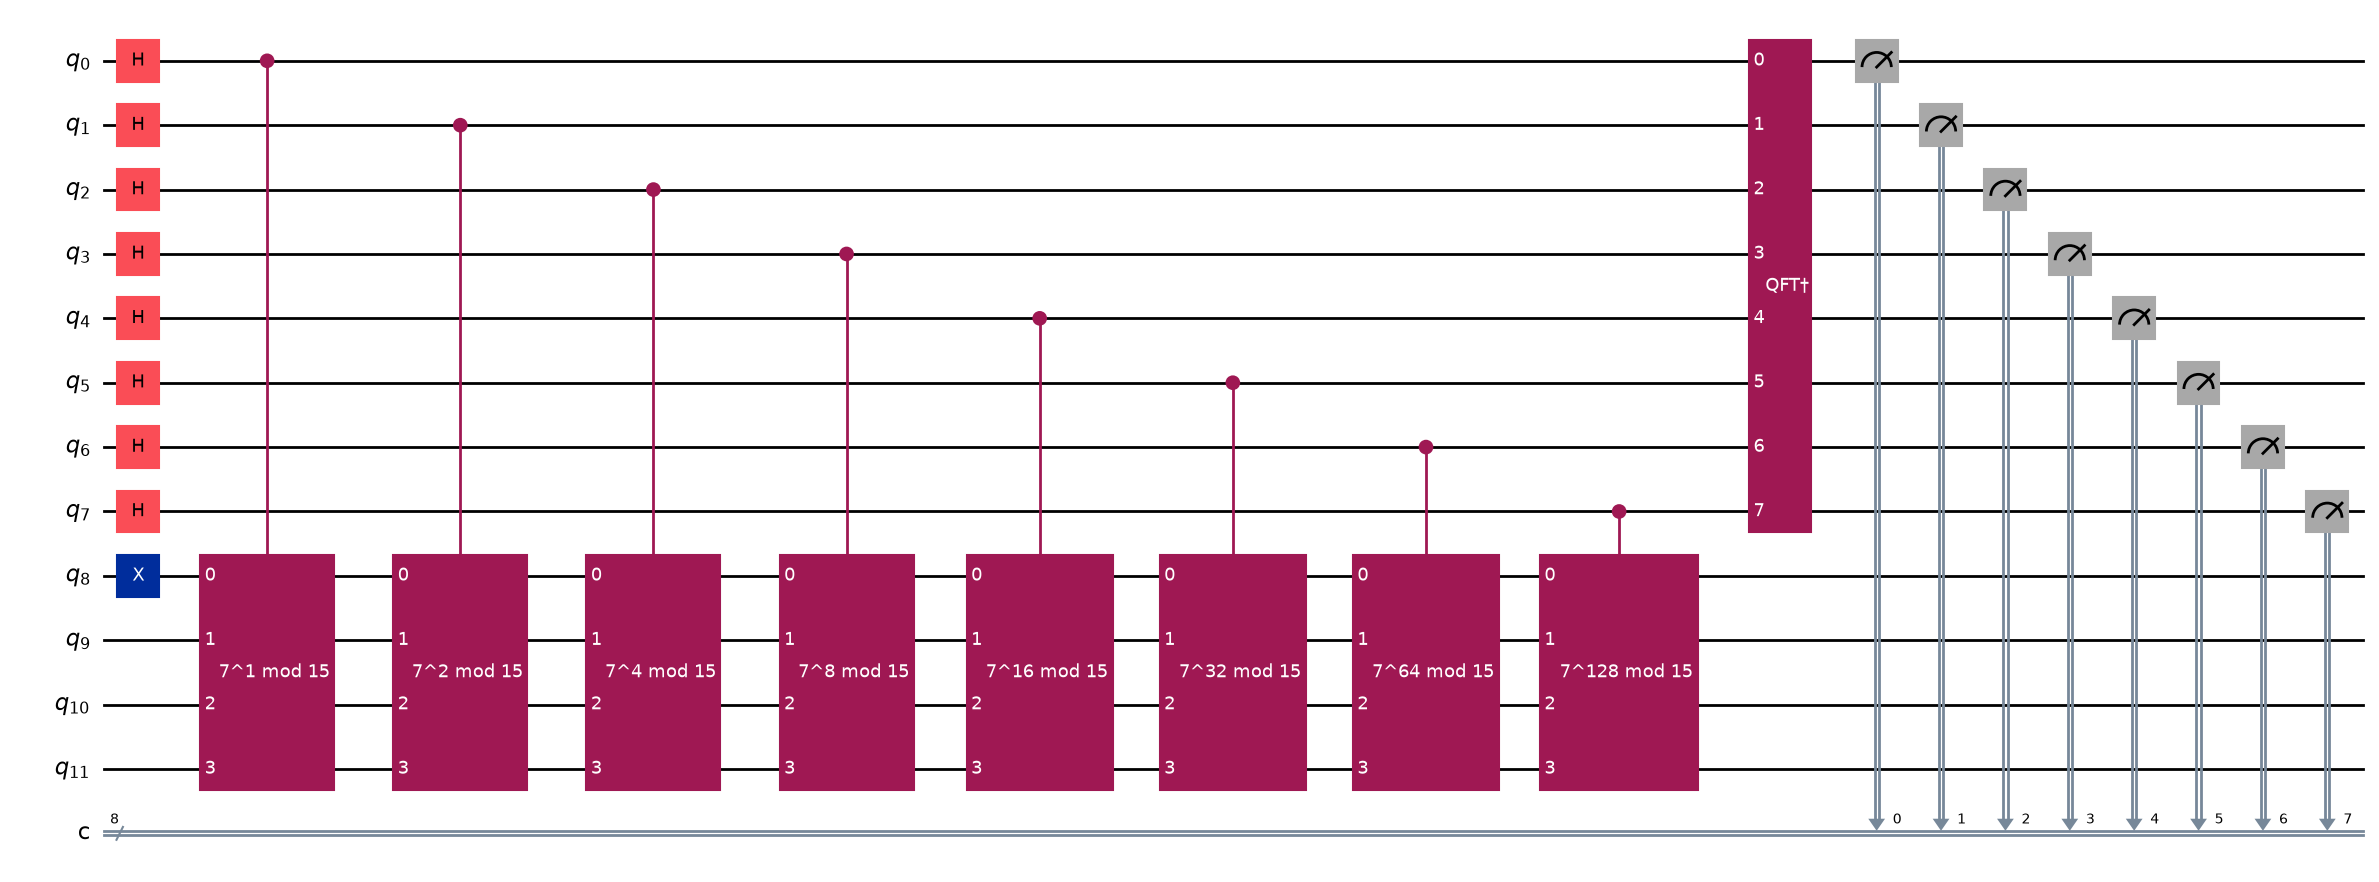

In [8]:
def shors_circuit(a, n_count):
    """
    Build the full Shor's algorithm circuit for factoring N=15.

    Parameters:
        a (int)       : base for modular exponentiation (use 7)
        n_count (int) : number of counting qubits (use 8)

    Returns:
        qc (QuantumCircuit) : the full Shor's circuit
    """
    # Create quantum and classical registers
    qc = QuantumCircuit(n_count + 4, n_count)
    # Qubits 0 to n_count-1 : counting register
    # Qubits n_count to n_count+3 : target register (4 qubits)

    # Step 1: Initialise target register — set qubit n_count to |1⟩
    qc.x(n_count)


    # Step 2: Apply Hadamard to all counting qubits
    for q in range(n_count):
        qc.h(q)


    # Step 3: Apply controlled-U^(2^j) gates
    for q in range(n_count):
        qc.append(
            c_amod15(a, 2**q),
            [q] + list(range(n_count, n_count + 4))
        )



    # Step 4: Apply inverse QFT to counting register
    qc.append(
        qft_dagger(n_count),
        range(n_count)
    )



    # Step 5: Measure counting register
    qc.measure(range(n_count), range(n_count))


    return qc


# Build and draw the circuit
a       = 7
n_count = 8
qc = shors_circuit(a, n_count)

print(f"Circuit width : {qc.num_qubits} qubits")
print(f"Circuit depth : {qc.depth()}")
print()
# Uncomment to draw (may be large):
qc.draw(output='mpl', fold=40)


## Testing shor's Circuit


In [10]:
qc = shors_circuit(7, 8)
print(qc.draw(fold=-1))

      ┌───┐                                                                                                                             ┌───────┐┌─┐                     
 q_0: ┤ H ├───────■─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤0      ├┤M├─────────────────────
      ├───┤       │                                                                                                                     │       │└╥┘┌─┐                  
 q_1: ┤ H ├───────┼──────────────■──────────────────────────────────────────────────────────────────────────────────────────────────────┤1      ├─╫─┤M├──────────────────
      ├───┤       │              │                                                                                                      │       │ ║ └╥┘┌─┐               
 q_2: ┤ H ├───────┼──────────────┼──────────────■───────────────────────────────────────────────────────────────────────────────────────┤2      ├─╫──╫

---
## Step 4 — Run on the Aer Simulator and Extract the Period (Your Task)

Run your circuit on the Qiskit Aer simulator, measure the output, and extract the period $r$.

### How to extract $r$ from the measurement results

The measurement gives you a value $y$ in the counting register. The relationship between $y$ and the period $r$ is:

$$\frac{y}{2^n} \approx \frac{k}{r} \quad \text{for some integer } k$$

Use Python's `Fraction` class to convert $y / 2^n$ to the closest fraction with a small denominator — the denominator is your candidate for $r$.

```python
phase = y / 2**n_count         # measured phase
frac  = Fraction(phase).limit_denominator(15)  # find closest fraction
r     = frac.denominator        # period candidate
```


In [9]:
# ── Run on Aer simulator ──────────────────────────────────────────────────────
simulator  = AerSimulator()
transpiled = transpile(qc, simulator)
job        = simulator.run(transpiled, shots=2048)
result     = job.result()
counts     = result.get_counts()

# Plot histogram
print("Measurement results (top outcomes):")
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
for bitstring, count in sorted_counts[:8]:
    print(f"  |{bitstring}⟩  :  {count} shots")

plot_histogram(counts, figsize=(12, 4), title="Shor's Algorithm — Simulator Results")
plt.tight_layout()
plt.show()


Measurement results (top outcomes):
  |11000000⟩  :  532 shots
  |10000000⟩  :  516 shots
  |01000000⟩  :  507 shots
  |00000000⟩  :  493 shots


<Figure size 640x480 with 0 Axes>

In [13]:
# ── Extract the period r from measurement results (Your Task) ─────────────────
print("Extracting period r from measured phases:\n")

rows = []
for bitstring, count in sorted_counts[:6]:
    # YOUR CODE HERE
    # Step 1: convert bitstring to integer
    y = int(bitstring, 2)

    # Step 2: compute the phase
    phase = y / (2 ** n_count)

    # Step 3: use Fraction to find the period candidate
    frac = Fraction(phase).limit_denominator(15)
    r = frac.denominator

    rows.append((bitstring, y, phase, r, count))
    print(f"  Bitstring: {bitstring}  →  y={y}  →  phase={phase:.4f}"
          f"  →  r candidate = {r}  (shots: {count})")

print()

Extracting period r from measured phases:

  Bitstring: 11000000  →  y=192  →  phase=0.7500  →  r candidate = 4  (shots: 532)
  Bitstring: 10000000  →  y=128  →  phase=0.5000  →  r candidate = 2  (shots: 516)
  Bitstring: 01000000  →  y=64  →  phase=0.2500  →  r candidate = 4  (shots: 507)
  Bitstring: 00000000  →  y=0  →  phase=0.0000  →  r candidate = 1  (shots: 493)



In [14]:
print("The most common non-zero r candidate is your period.")
print("Confirm: does 7^r mod 15 == 1?")
# YOUR CODE HERE — check if pow(7, r, 15) == 1 for your r
print(pow(7, 4, 15) == 1)

The most common non-zero r candidate is your period.
Confirm: does 7^r mod 15 == 1?
True


The measurement outcomes produced phases 0, 1/4, 1/2, and 3/4. The non-trivial phases 1/4 and 3/4 yield denominator 4 when converted to fractions, indicating that the period of 7
x
mod15 is r=4. The result is verified since 7
4
≡1(mod15).

---
## Step 5 — Classical Post-Processing: Find the Factors (Your Task)

Now use the period $r$ you found to compute the factors of $N = 15$ using **Euler's theorem**:

$$\text{factors} = \gcd(a^{r/2} \pm 1,\; N)$$

### Conditions for this to work
1. $r$ must be **even**
2. $a^{r/2} \not\equiv -1 \pmod{N}$ (i.e., $a^{r/2} \bmod N \neq N - 1$)

If either condition fails, you need to try a different $a$. For $a = 7$, $r = 4$, both conditions are satisfied — verify this below.


In [15]:
# ── Classical post-processing (Your Task) ─────────────────────────────────────
a = 7
N = 15

# Use the period r you found in Step 4
# Replace the value below with your measured r
r = 4  # YOUR CODE HERE — set r to the period you found

if r is None:
    print("Set r to your measured period from Step 4 first.")
else:
    print(f"Using a = {a}, N = {N}, r = {r}")
    print()

    # Check condition 1: r must be even
    # YOUR CODE HERE
    if r % 2 != 0: 
        print("r is odd — try a different value of a.")
    else:
        print(f"✅ r = {r} is even")

        # Check condition 2: a^(r/2) mod N != N-1
        # YOUR CODE HERE
        ar2 = pow(a, r//2, N)
        
        print(f"   a^(r/2) mod N = {pow(a, r//2, N)}")
        if pow(a, r//2, N) == N - 1:
            print("a^(r/2) ≡ -1 (mod N) — try a different value of a.")
        else:
            print(f"✅ Condition 2 satisfied")
            print()

            # Compute the two factor candidates
            # YOUR CODE HERE
            factor1 = gcd(pow(a, r//2) - 1, N)
            factor2 = gcd(pow(a, r//2) + 1, N)

            print(f"Factor candidates: gcd(a^(r/2) - 1, N) = {factor1}")
            print(f"                   gcd(a^(r/2) + 1, N) = {factor2}")
            print()

            # Verify
            if factor1 and factor2:
                if factor1 * factor2 == N:
                    print(f"🎉 Successfully factored {N} = {factor1} × {factor2}")
                else:
                    print(f"Factors {factor1} and {factor2} — check your r value")


Using a = 7, N = 15, r = 4

✅ r = 4 is even
   a^(r/2) mod N = 4
✅ Condition 2 satisfied

Factor candidates: gcd(a^(r/2) - 1, N) = 3
                   gcd(a^(r/2) + 1, N) = 5

🎉 Successfully factored 15 = 3 × 5


---
## Step 6 — Run on Real IBM Quantum Hardware

Now run your circuit on a real IBM Quantum processor and compare the results with the simulator.

### Setup
You will need your **IBM Quantum API token**. Get it from [quantum.ibm.com](https://quantum.ibm.com) → Account → API Token.

> **Note:** Real hardware results will be noisier than the simulator. You may see different measurement distributions, but the correct period should still appear as one of the top outcomes.


In [16]:
# ── Connect to IBM Quantum (Your Task) ───────────────────────────────────────
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# Save your IBM Quantum account (only needed once)
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="Your Token_ID",
    overwrite=True
)

# Load account
service = QiskitRuntimeService()

# Select the least busy backend with enough qubits
# YOUR CODE HERE

backend = QiskitRuntimeService().least_busy(simulator=False, operational=True, min_num_qubits=12)
print("Selected backend:", backend.name)


qiskit_runtime_service.__init__:WARNING:2026-06-20 17:00:48,756: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-06-20 17:00:54,372: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:20

Selected backend: ibm_kingston


In [17]:
# ── Transpile and run on real hardware (Your Task) ────────────────────────────
if backend is not None:
    # Transpile for the selected backend
    qc_transpiled = transpile(qc, backend, optimization_level=3)
    print(f"Transpiled circuit depth: {qc_transpiled.depth()}")

    # Run using SamplerV2
    sampler = Sampler(backend)
    job_hw  = sampler.run([qc_transpiled], shots=1024)
    print(f"Job ID: {job_hw.job_id()}")
    print("Job submitted. This may take a few minutes depending on queue length.")
    print("Check status at: https://quantum.ibm.com/jobs")


Transpiled circuit depth: 86127
Job ID: d8r7kqmab0ds73drbfa0
Job submitted. This may take a few minutes depending on queue length.
Check status at: https://quantum.ibm.com/jobs


In [18]:
print(job_hw.status())

DONE


Hardware results (top 8 outcomes):
  |01000000⟩  :  114 shots
  |01000001⟩  :  90 shots
  |10000000⟩  :  54 shots
  |00000001⟩  :  54 shots
  |00000000⟩  :  51 shots
  |00111111⟩  :  48 shots
  |10000001⟩  :  40 shots
  |01000010⟩  :  33 shots


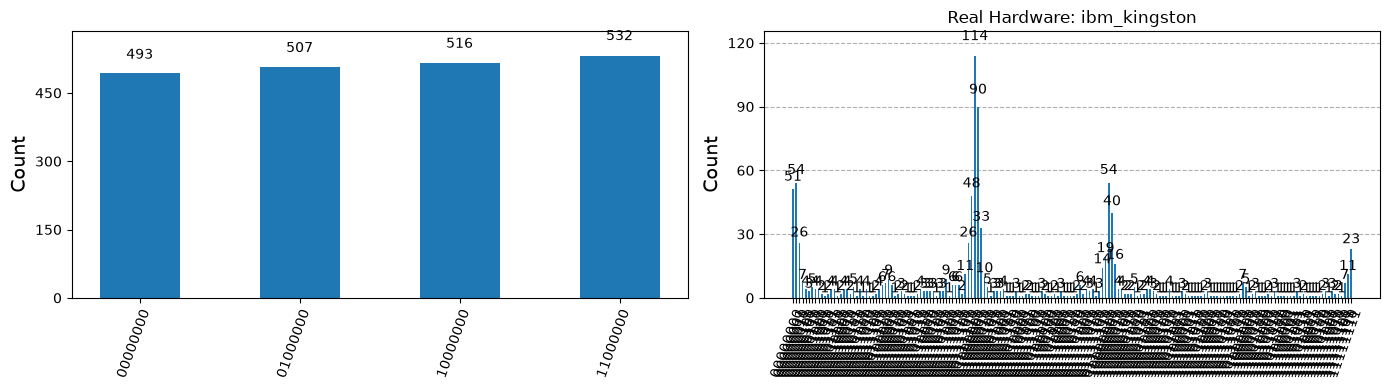


Compare: does the hardware give the same period r?


In [19]:
# ── Retrieve and plot hardware results (Your Task) ────────────────────────────
# Run this cell after your job completes

if backend is not None:
    result_hw  = job_hw.result()
    counts_hw  = result_hw[0].data.c.get_counts()

    print(f"Hardware results (top 8 outcomes):")
    sorted_hw = sorted(counts_hw.items(), key=lambda x: x[1], reverse=True)
    for bitstring, count in sorted_hw[:8]:
        print(f"  |{bitstring}⟩  :  {count} shots")

    # Plot side-by-side comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    plot_histogram(counts,    ax=ax1, title="Simulator Results")
    plot_histogram(counts_hw, ax=ax2, title=f"Real Hardware: {backend.name}")
    plt.tight_layout()
    plt.show()

    # YOUR CODE HERE — extract r from hardware results and compare with simulator
    print()
    print("Compare: does the hardware give the same period r?")


In [23]:
from fractions import Fraction

print("\nTop hardware outcomes interpreted:")

sorted_hw = sorted(counts_hw.items(), key=lambda x: x[1], reverse=True)

for bitstring, count in sorted_hw[:8]:
    y = int(bitstring, 2)
    phase = y / (2 ** n_count)

    frac = Fraction(phase).limit_denominator(15)
    r_candidate = frac.denominator

    print(
        f"{bitstring} -> phase={phase:.4f} -> "
        f"r candidate={r_candidate} ({count} shots)"
    )
    


Top hardware outcomes interpreted:
01000000 -> phase=0.2500 -> r candidate=4 (114 shots)
01000001 -> phase=0.2539 -> r candidate=4 (90 shots)
10000000 -> phase=0.5000 -> r candidate=2 (54 shots)
00000001 -> phase=0.0039 -> r candidate=1 (54 shots)
00000000 -> phase=0.0000 -> r candidate=1 (51 shots)
00111111 -> phase=0.2461 -> r candidate=4 (48 shots)
10000001 -> phase=0.5039 -> r candidate=2 (40 shots)
01000010 -> phase=0.2578 -> r candidate=4 (33 shots)


In [24]:
print("\nSimulator period: r = 4")
print("Hardware result: noisy but consistent with r = 4")


Simulator period: r = 4
Hardware result: noisy but consistent with r = 4


The real IBM Quantum hardware produced a noisier measurement distribution compared to the simulator. This is expected due to hardware imperfections such as gate errors, decoherence, and measurement noise. However, the dominant outcomes remained clustered around the expected phase values, allowing recovery of the same period r = 4 obtained from the simulator. Using this period, the classical post-processing stage successfully factored N = 15 into 3 and 5. Thus, Shor's algorithm was successfully demonstrated on both a simulator and real quantum hardware.


---
## Summary

Complete the table below in this cell before submitting:

| Step | Task | Result |
|------|------|--------|
| 1 | Modular exponentiation oracle | Pre-written ✅ |
| 2 | Inverse QFT circuit | Implemented ✅ |
| 3 | Full Shor's circuit | Built and Simulated ✅ |
| 4 | Period $r$ (from simulator) | r =4 |
| 5 | Factors of $N = 15$ | 15 = 3 × 5 |
| 6 | Period $r$ (from real hardware) | r =4 (same period recovered despite noise) |

### Reflection questions (answer briefly below each question)

**Q1.** The simulator gives a clean distribution of peaks. Why is the hardware result noisier?

*Real quantum hardware is affected by gate errors, decoherence, qubit relaxation, and measurement errors. These imperfections introduce noise into the computation, causing extra measurement outcomes and broader peaks compared to the ideal simulator.*

**Q2.** Why does the QFT output give us the period rather than the answer directly?

*The modular exponentiation oracle encodes information about the period into the phase of the quantum state. The Quantum Fourier Transform converts this phase information into measurable frequencies, from which the period r can be extracted using classical post-processing. Therefore, QFT reveals the period instead of directly outputting the factors.*

**Q3.** Shor's algorithm threatens RSA encryption. Why doesn't factoring $N = 15$ on a quantum computer worry cryptographers today?

*Factoring N = 15 is only a small demonstration of Shor's algorithm. Modern RSA uses integers with hundreds or thousands of bits (e.g., RSA-2048). Current quantum computers do not have enough high-quality qubits or low enough error rates to factor such large numbers, so practical RSA encryption remains secure for now.*

---
*QC101 · 4i Labs Quantum Computing Domain · IIT Guwahati · Tenure 2026–27*
